p-LAPLACIANO Y SU CONEXIÓN CON TEORÍA DE CUERDAS Y BRANAS

>>> Parte A — p-Laplaciano 1D (analítico)


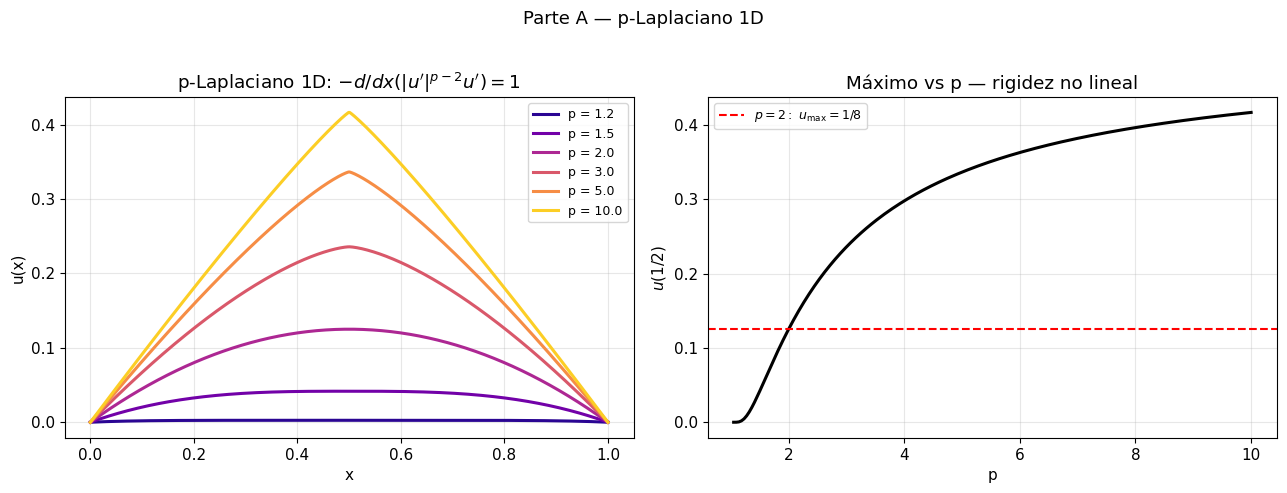


>>> Parte B — p-Laplaciano 2D (Picard + matriz)


/usr/local/lib/python3.13/dist-packages/IPython/core/pylabtools.py:151: UserWarning: This figure includes Axes that are not compatible with tight_layout, so results might be incorrect.
  fig.canvas.print_figure(bytes_io, **kw)


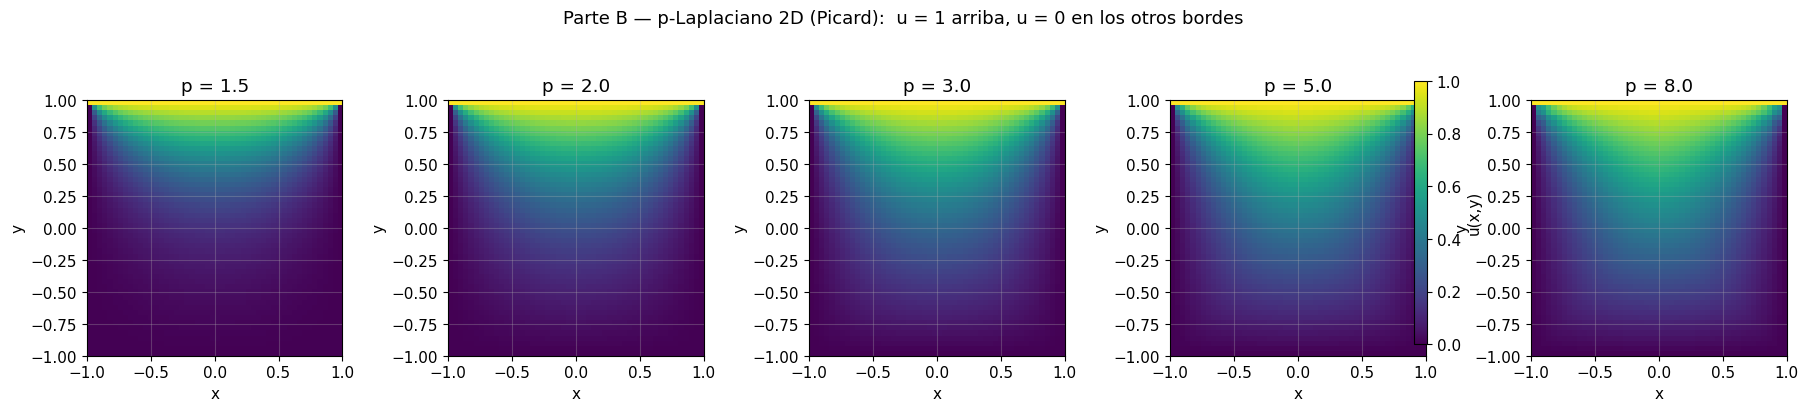

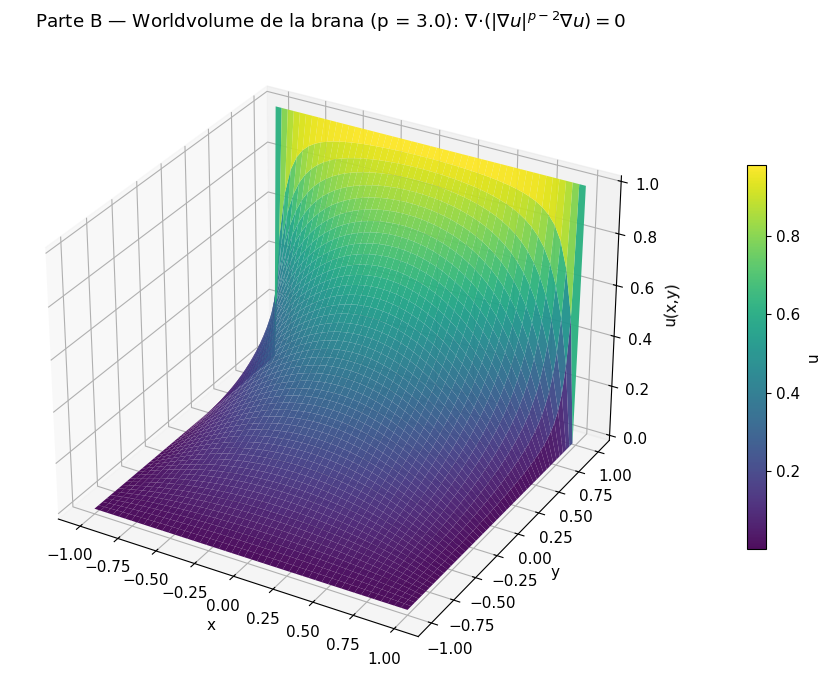


>>> Parte C — DBI vs p-Laplaciano (Picard + matriz)


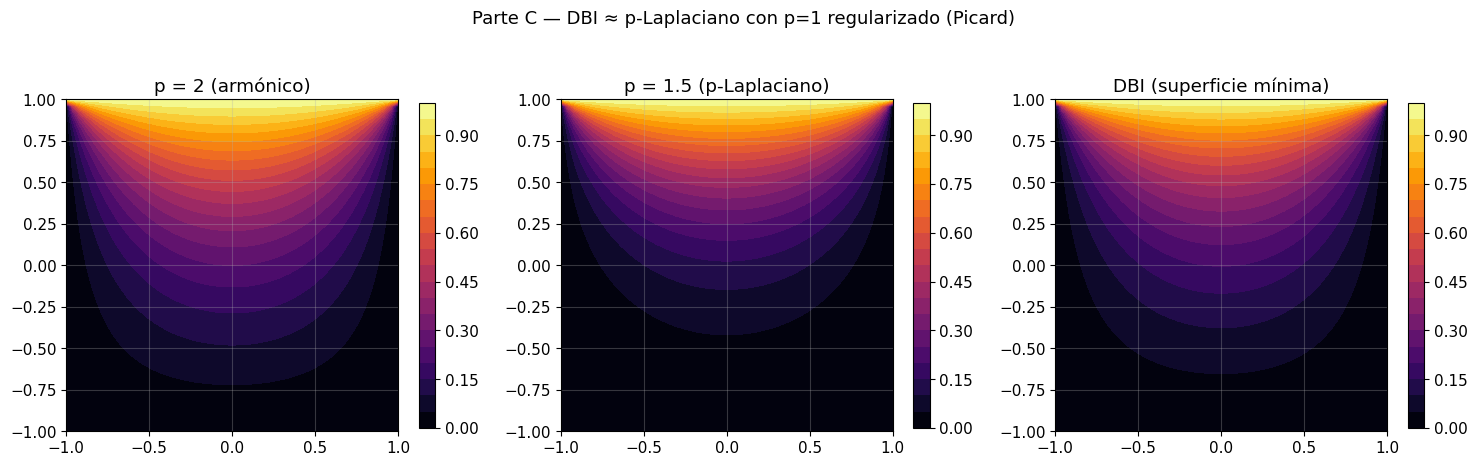

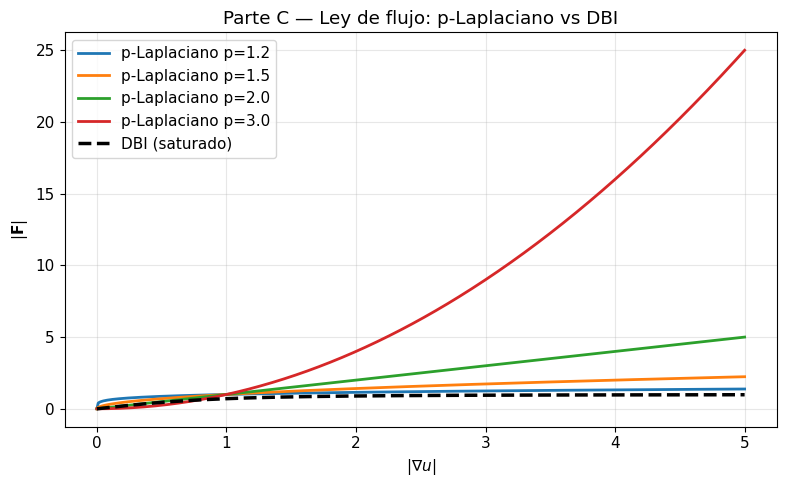


>>> Parte D — p-difusión (evolución)


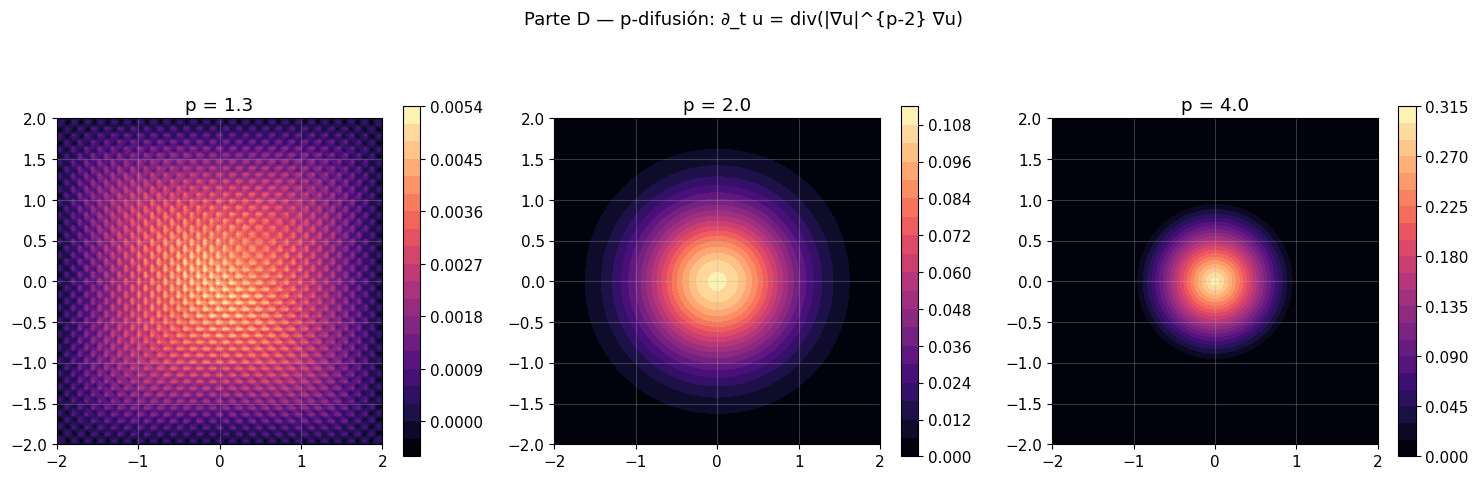


>>> Parte E — Brana como superficie mínima


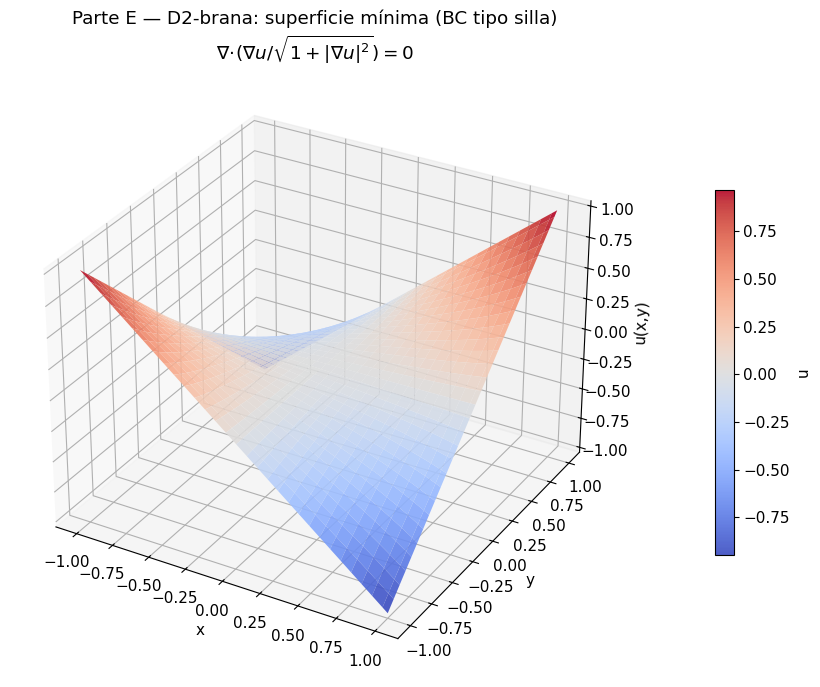


FIN


In [1]:
# ============================================================
# p-LAPLACIANO, SUPERFICIES MÍNIMAS Y BRANAS
# (Parte A, D, E: esquema original; Parte B, C: Picard + matriz)
# ============================================================
%matplotlib inline

import numpy as np
import matplotlib.pyplot as plt
from matplotlib import cm
import scipy.sparse as sp
import scipy.sparse.linalg as spla

plt.rcParams.update({
    "font.size": 11, "axes.grid": True,
    "grid.alpha": 0.3, "figure.autolayout": True,
})


# ============================================================
# PARTE A — p-LAPLACIANO EN 1D (solución analítica)
# ------------------------------------------------------------
# Ecuación:  -d/dx( |u'|^{p-2} u' ) = 1,   u(0) = u(1) = 0
#
# Solución analítica:
#   u(x) = (p-1)/p * [ (1/2)^{p/(p-1)} - |x - 1/2|^{p/(p-1)} ]
# ============================================================
def parte_A_1d():
    plt.close("all")
    x = np.linspace(0, 1, 500)

    fig, axs = plt.subplots(1, 2, figsize=(13, 4.8))

    ps = [1.2, 1.5, 2.0, 3.0, 5.0, 10.0]
    colores = cm.plasma(np.linspace(0.05, 0.9, len(ps)))

    for p, col in zip(ps, colores):
        q     = p / (p - 1)
        u_ana = (p - 1) / p * ((1/2)**q - np.abs(x - 1/2)**q)
        axs[0].plot(x, u_ana, color=col, lw=2.2, label=f"p = {p}")

    axs[0].set_xlabel("x"); axs[0].set_ylabel("u(x)")
    axs[0].set_title(r"p-Laplaciano 1D: $-d/dx(|u'|^{p-2}u')=1$")
    axs[0].legend(fontsize=9)

    p_arr = np.linspace(1.05, 10, 200)
    u_centro = (p_arr - 1) / p_arr * (1/2)**(p_arr/(p_arr-1))
    axs[1].plot(p_arr, u_centro, 'k-', lw=2.2)
    axs[1].axhline(1/8, color='r', ls='--', lw=1.5,
                   label=r"$p=2:\ u_{\max}=1/8$")
    axs[1].set_xlabel("p"); axs[1].set_ylabel(r"$u(1/2)$")
    axs[1].set_title("Máximo vs p — rigidez no lineal")
    axs[1].legend(fontsize=9)

    plt.suptitle("Parte A — p-Laplaciano 1D", fontsize=13, y=1.02)
    plt.show()


# ============================================================
# SOLVER PICARD + MATRIZ  (usado en B y C)
# ------------------------------------------------------------
# Resuelve  div( D(∇u) ∇u ) = 0  por iteración de Picard:
#   se congela D^k = D(∇u^k) y se resuelve el sistema lineal
#   div(D^k ∇u^{k+1}) = 0  (A\b directo, coeficientes en caras).
# ============================================================
def resolver_picard(N, D_func, u_bc, x1=-1.0, x2=1.0,
                     max_picard=200, tol=1e-7, omega=1.0):
    x = np.linspace(x1, x2, N)
    dx = x[1] - x[0]
    u = u_bc.copy()
    n = N - 2
    idx = np.arange(n * n).reshape(n, n)

    for k in range(max_picard):
        ux = np.zeros_like(u); uy = np.zeros_like(u)
        ux[1:-1, 1:-1] = (u[2:, 1:-1] - u[:-2, 1:-1]) / (2 * dx)
        uy[1:-1, 1:-1] = (u[1:-1, 2:] - u[1:-1, :-2]) / (2 * dx)
        Dself = D_func(ux[1:-1, 1:-1], uy[1:-1, 1:-1])

        # coeficientes promediados en las 4 caras
        Dp = np.empty((n, n)); Dm = np.empty((n, n))
        De = np.empty((n, n)); Dw = np.empty((n, n))
        Dp[:-1, :] = 0.5 * (Dself[:-1, :] + Dself[1:, :]); Dp[-1, :] = Dself[-1, :]
        Dm[1:, :]  = 0.5 * (Dself[1:, :] + Dself[:-1, :]); Dm[0, :]  = Dself[0, :]
        De[:, :-1] = 0.5 * (Dself[:, :-1] + Dself[:, 1:]); De[:, -1] = Dself[:, -1]
        Dw[:, 1:]  = 0.5 * (Dself[:, 1:] + Dself[:, :-1]); Dw[:, 0]  = Dself[:, 0]

        diag = (Dp + Dm + De + Dw).flatten()
        rows = np.concatenate([idx.flatten(),
                               idx[:-1, :].flatten(), idx[1:, :].flatten(),
                               idx[:, :-1].flatten(), idx[:, 1:].flatten()])
        cols = np.concatenate([idx.flatten(),
                               idx[1:, :].flatten(),  idx[:-1, :].flatten(),
                               idx[:, 1:].flatten(),  idx[:, :-1].flatten()])
        data = np.concatenate([diag,
                               -Dp[:-1, :].flatten(), -Dm[1:, :].flatten(),
                               -De[:, :-1].flatten(), -Dw[:, 1:].flatten()])
        A = sp.csr_matrix((data, (rows, cols)), shape=(n * n, n * n))

        b = np.zeros(n * n)
        b[idx[-1, :]] += Dp[-1, :] * u_bc[-1, 1:-1]
        b[idx[0, :]]  += Dm[0, :]  * u_bc[0, 1:-1]
        b[idx[:, -1]] += De[:, -1] * u_bc[1:-1, -1]
        b[idx[:, 0]]  += Dw[:, 0]  * u_bc[1:-1, 0]

        u_int = spla.spsolve(A, b)
        u_solve = u_bc.copy()
        u_solve[1:-1, 1:-1] = u_int.reshape(n, n)

        u_new = (1 - omega) * u + omega * u_solve
        if np.max(np.abs(u_new - u)) < tol:
            u = u_new
            break
        u = u_new

    return x, u


# ============================================================
# PARTE B — p-LAPLACIANO EN 2D (Picard + matriz)
# Resuelve:  Δ_p u = 0   en [-1,1]²
# BC:        u = 1 en el borde SUPERIOR (y = +1)
#            u = 0 en los otros tres bordes
# ============================================================
def parte_B_2d():
    plt.close("all")
    N = 50
    u_bc = np.zeros((N, N)); u_bc[-1, :] = 1.0
    ps = [1.5, 2.0, 3.0, 5.0, 8.0]
    sols = {}

    for p in ps:
        eps = 0.02
        omega = 1.0 if p <= 2.5 else (0.5 if p <= 5 else 0.3)
        D = lambda ux, uy, p=p, eps=eps: (ux**2 + uy**2 + eps**2) ** ((p - 2) / 2)
        x, u = resolver_picard(N, D, u_bc, omega=omega, max_picard=300)
        sols[p] = u

    # --- Mosaico 2D ---
    fig, axs = plt.subplots(1, len(ps), figsize=(18, 3.8))
    for ax, p in zip(axs, ps):
        im = ax.imshow(sols[p], extent=[-1, 1, -1, 1], origin="lower",
                       cmap="viridis", vmin=0, vmax=1)
        ax.set_title(f"p = {p}")
        ax.set_xlabel("x"); ax.set_ylabel("y")
    fig.colorbar(im, ax=axs, shrink=0.9, label="u(x,y)")
    plt.suptitle("Parte B — p-Laplaciano 2D (Picard):  u = 1 arriba, u = 0 en los otros bordes",
                 y=1.03, fontsize=13)
    plt.show()

    # --- Superficie 3D representativa ---
    p_show = 3.0
    X, Y = np.meshgrid(x, x)
    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, sols[p_show], cmap="viridis",
                           linewidth=0, antialiased=True,
                           rstride=1, cstride=1, alpha=0.95)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("u(x,y)")
    ax.set_title(f"Parte B — Worldvolume de la brana (p = {p_show}): "
                 r"$\nabla\!\cdot\!(|\nabla u|^{p-2}\nabla u)=0$")
    fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label="u")
    plt.show()


# ============================================================
# PARTE C — DBI vs p-LAPLACIANO (Picard + matriz)
# ------------------------------------------------------------
# DBI estático:  div( ∇u / √(1 + |∇u|²) ) = 0
# (p-Laplaciano con p=1 regularizado)
# ============================================================
def parte_C_dbi_vs_plaplace():
    plt.close("all")
    N = 50
    u_bc = np.zeros((N, N)); u_bc[-1, :] = 1.0

    D_dbi = lambda ux, uy: 1.0 / np.sqrt(1.0 + ux**2 + uy**2)
    D_p2  = lambda ux, uy: (ux**2 + uy**2 + 0.02**2) ** 0.0          # p=2
    D_p15 = lambda ux, uy: (ux**2 + uy**2 + 0.02**2) ** (-0.25)      # p=1.5

    x, u_dbi = resolver_picard(N, D_dbi, u_bc, omega=0.6, max_picard=200)
    _, u_p2  = resolver_picard(N, D_p2,  u_bc, omega=1.0, max_picard=200)
    _, u_p15 = resolver_picard(N, D_p15, u_bc, omega=1.0, max_picard=200)

    # --- Mosaico comparativo ---
    fig, axs = plt.subplots(1, 3, figsize=(15, 4.5))
    for ax, u, titulo in zip(axs,
                             [u_p2, u_p15, u_dbi],
                             ["p = 2 (armónico)",
                              "p = 1.5 (p-Laplaciano)",
                              "DBI (superficie mínima)"]):
        cs = ax.contourf(x, x, u, levels=20, cmap="inferno")
        ax.set_aspect("equal")
        ax.set_title(titulo)
        fig.colorbar(cs, ax=ax, shrink=0.85)

    plt.suptitle("Parte C — DBI ≈ p-Laplaciano con p=1 regularizado (Picard)",
                 fontsize=13, y=1.03)
    plt.show()

    # --- Ley de flujo ---
    g = np.linspace(0, 5, 500)
    plt.figure(figsize=(8, 5))
    for p in [1.2, 1.5, 2.0, 3.0]:
        plt.plot(g, g**(p-1), lw=2, label=f"p-Laplaciano p={p}")
    plt.plot(g, g / np.sqrt(1 + g**2), 'k--', lw=2.5,
             label="DBI (saturado)")
    plt.xlabel(r"$|\nabla u|$"); plt.ylabel(r"$|\mathbf{F}|$")
    plt.title("Parte C — Ley de flujo: p-Laplaciano vs DBI")
    plt.legend(); plt.grid(alpha=0.3)
    plt.show()


# ============================================================
# PARTE D — EVOLUCIÓN p-CALÓRICA (difusión no lineal)
# ∂_t u = div( |∇u|^{p-2} ∇u )
# ============================================================
def parte_D_evolucion():
    plt.close("all")

    N = 100
    x = np.linspace(-2, 2, N)
    dx = x[1] - x[0]
    X, Y = np.meshgrid(x, x)

    fig, axs = plt.subplots(1, 3, figsize=(15, 4.8))

    for ax, p in zip(axs, [1.3, 2.0, 4.0]):
        u = np.exp(-((X)**2 + (Y)**2) / 0.1)
        dt = 0.05 * dx**2
        for _ in range(2500):
            ux, uy = np.gradient(u, dx)
            gmag = np.sqrt(ux**2 + uy**2 + 1e-8)
            coeff = gmag**(p - 2)
            Fx = coeff * ux
            Fy = coeff * uy
            dFx, _ = np.gradient(Fx, dx)
            _, dFy = np.gradient(Fy, dx)
            lap = dFx + dFy
            u[1:-1, 1:-1] += dt * lap[1:-1, 1:-1]

        cs = ax.contourf(X, Y, u, levels=20, cmap="magma")
        ax.set_aspect("equal")
        ax.set_title(f"p = {p}")
        fig.colorbar(cs, ax=ax, shrink=0.85)

    plt.suptitle("Parte D — p-difusión: ∂_t u = div(|∇u|^{p-2} ∇u)",
                 fontsize=13, y=1.03)
    plt.show()


# ============================================================
# PARTE E — BRANA COMO SUPERFICIE MÍNIMA
# BC tipo silla de montar → catenoide discreto
# ============================================================
def parte_E_brana_superficie():
    plt.close("all")

    N = 60
    x = np.linspace(-1, 1, N)
    X, Y = np.meshgrid(x, x)
    u_bc = X * Y

    u = u_bc.copy()
    dx = x[1] - x[0]
    dt = 0.05 * dx**2

    for _ in range(6000):
        ux, uy = np.gradient(u, dx)
        denom = np.sqrt(1.0 + ux**2 + uy**2 + 1e-10)
        Fx = ux / denom
        Fy = uy / denom
        dFx, _ = np.gradient(Fx, dx)
        _, dFy = np.gradient(Fy, dx)
        lap = dFx + dFy
        u[1:-1, 1:-1] += dt * lap[1:-1, 1:-1]
        u[0, :]  = u_bc[0, :];  u[-1, :] = u_bc[-1, :]
        u[:, 0]  = u_bc[:, 0];  u[:, -1] = u_bc[:, -1]

    fig = plt.figure(figsize=(10, 7))
    ax = fig.add_subplot(111, projection="3d")
    surf = ax.plot_surface(X, Y, u, cmap="coolwarm", linewidth=0,
                           antialiased=True, rstride=2, cstride=2,
                           alpha=0.9)
    ax.set_xlabel("x"); ax.set_ylabel("y"); ax.set_zlabel("u(x,y)")
    ax.set_title("Parte E — D2-brana: superficie mínima (BC tipo silla)\n"
                 r"$\nabla\!\cdot\!(\nabla u/\sqrt{1+|\nabla u|^2})=0$")
    fig.colorbar(surf, ax=ax, shrink=0.6, pad=0.1, label="u")
    plt.show()


# ============================================================
# EJECUCIÓN EN ORDEN CORRECTO
# ============================================================
print("=" * 70)
print("p-LAPLACIANO Y SU CONEXIÓN CON TEORÍA DE CUERDAS Y BRANAS")
print("=" * 70)

print("\n>>> Parte A — p-Laplaciano 1D (analítico)")
parte_A_1d()

print("\n>>> Parte B — p-Laplaciano 2D (Picard + matriz)")
parte_B_2d()

print("\n>>> Parte C — DBI vs p-Laplaciano (Picard + matriz)")
parte_C_dbi_vs_plaplace()

print("\n>>> Parte D — p-difusión (evolución)")
parte_D_evolucion()

print("\n>>> Parte E — Brana como superficie mínima")
parte_E_brana_superficie()

print("\n" + "=" * 70)
print("FIN")
print("=" * 70)